# ROOTKey A/B Test Analysis Notebook

*This analysis uses the professor-provided BDS landing page dataset. Our group ID is TXC_9. We rename generic variables to match our context: `kpi_y` → `cta_click` (primary KPI), `kpi_x` → `engagement_score` (guiderail).*


In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display settings
sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Colour palette
BLUE  = '#2563EB'   # Treatment (B)
GREEN = '#16A34A'   # Positive / thresholds
RED   = '#DC2626'   # Warnings / rejection regions
GRAY  = '#6B7280'   # Control (A)

In [3]:
# Load raw dataset
df_raw = pd.read_csv('TXC_9_landingpage.csv')

print(f'Raw dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print()
print(df_raw['arm'].value_counts().rename('N').to_frame())

Raw dataset: 654 rows × 16 columns

             N
arm           
control    255
treatment  247
pre        152


---
## 1. Power Calculation

Done before looking at the data. We use the pre-period CTA click rate from the 
professor's dataset as our baseline p_A, and set a minimum detectable effect of 
2pp, the smallest lift we would consider meaningful given the scope of the 
four structural changes made in Version B. At a 2.63% baseline, a 2pp lift 
represents a ~76% relative increase.

**n = ( (Z₁₋α/₂ + Z₁₋β)² · σ² ) / δ²**

- σ² = p·(1−p): variance of a binary outcome
- δ = 0.02: minimum detectable effect
- α = 0.05, power = 80%


In [4]:
# Baseline metrics from pre-period
pre = df_raw[df_raw['arm'] == 'pre'].copy()
pre = pre.rename(columns={'kpi_y': 'cta_click', 'kpi_x': 'engagement_score'})

print('Pre-period Baseline Metrics')
print('=' * 40)
print(f'  Observations:        {len(pre)}')
print(f'  CTA click rate:      {pre["cta_click"].mean()*100:.2f}%')
print(f'  Engagement score:    {pre["engagement_score"].mean():.3f}  (SD={pre["engagement_score"].std():.3f})')
print(f'  Scroll depth (%):    {pre["scroll_depth_pct"].mean():.2f}  (SD={pre["scroll_depth_pct"].std():.2f})')
print()
print('  -> Use CTA click rate as p_A in power calculation')

p_A_baseline = pre['cta_click'].mean()
print(f'  p_A = {p_A_baseline:.4f}')

Pre-period Baseline Metrics
  Observations:        152
  CTA click rate:      2.63%
  Engagement score:    30.920  (SD=26.940)
  Scroll depth (%):    37.49  (SD=32.00)

  -> Use CTA click rate as p_A in power calculation
  p_A = 0.0263


In [5]:
p_A     = p_A_baseline
delta   = 0.02
alpha   = 0.05
power_t = 0.80

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta  = stats.norm.ppf(power_t)
sigma2  = p_A * (1 - p_A)

n_per_group = int(np.ceil((z_alpha + z_beta)**2 * sigma2 / delta**2))
n_total     = n_per_group * 2

print(f'Baseline conversion (p_A):     {p_A*100:.2f}%')
print(f'Min detectable effect (delta): {delta*100:.0f}pp')
print(f'sigma^2 = p*(1-p):             {sigma2:.4f}')
print(f'Z_alpha/2:                     {z_alpha:.3f}')
print(f'Z_beta:                        {z_beta:.3f}')
print()
print(f'Required n per group:          {n_per_group}')
print(f'Required total (50/50):        {n_total}')


Baseline conversion (p_A):     2.63%
Min detectable effect (delta): 2pp
sigma^2 = p*(1-p):             0.0256
Z_alpha/2:                     1.960
Z_beta:                        0.842

Required n per group:          503
Required total (50/50):        1006


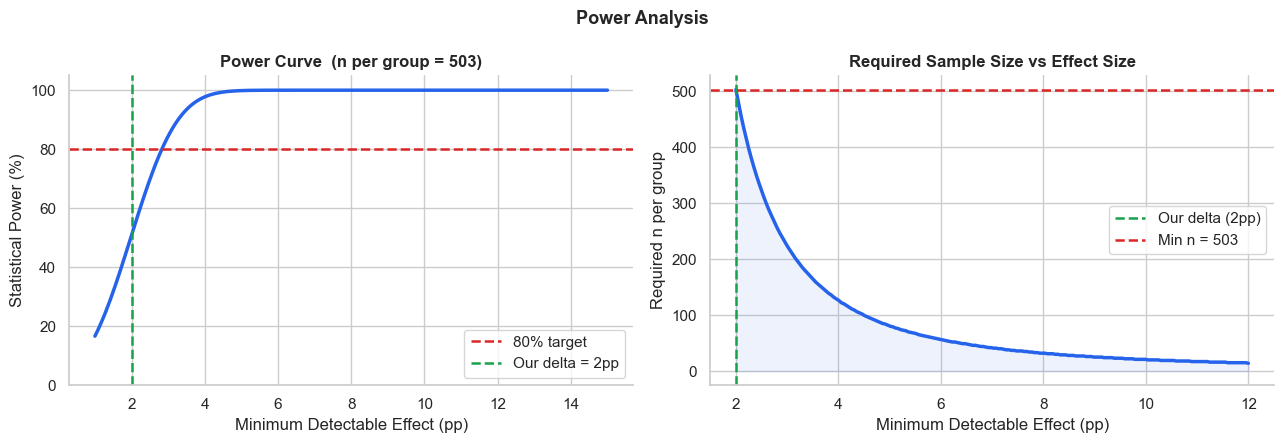

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

effects = np.linspace(0.01, 0.15, 200)
powers  = [stats.norm.cdf(e / np.sqrt(2 * sigma2 / n_per_group) - z_alpha) * 100
           for e in effects]
axes[0].plot([e*100 for e in effects], powers, color=BLUE, lw=2.5)
axes[0].axhline(80, color=RED, ls='--', lw=1.8, label='80% target')
axes[0].axvline(delta*100, color=GREEN, ls='--', lw=1.8, label=f'Our delta = {delta*100:.0f}pp')
axes[0].set_xlabel('Minimum Detectable Effect (pp)')
axes[0].set_ylabel('Statistical Power (%)')
axes[0].set_title(f'Power Curve  (n per group = {n_per_group})', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 105)
axes[0].spines[['top','right']].set_visible(False)

effects_r = np.linspace(0.02, 0.12, 200)
ns = [int(np.ceil((z_alpha + z_beta)**2 * sigma2 / e**2)) for e in effects_r]
axes[1].plot([e*100 for e in effects_r], ns, color=BLUE, lw=2.5)
axes[1].axvline(delta*100, color=GREEN, ls='--', lw=1.8, label=f'Our delta ({delta*100:.0f}pp)')
axes[1].axhline(n_per_group, color=RED, ls='--', lw=1.8, label=f'Min n = {n_per_group}')
axes[1].fill_between([e*100 for e in effects_r], ns, alpha=0.08, color=BLUE)
axes[1].set_xlabel('Minimum Detectable Effect (pp)')
axes[1].set_ylabel('Required n per group')
axes[1].set_title('Required Sample Size vs Effect Size', fontweight='bold')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Power Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Power Calculation Explained

Using the pre-period baseline CTA click rate of 2.63% as p_A and a minimum 
detectable effect of 2pp, we need a minimum of 503 visitors per group, or 
1,006 total, to achieve 80% power at α = 0.05. Both the control (255) and 
treatment (247) groups fall well short of this threshold, meaning the experiment 
is underpowered to detect an effect of this size. Any null result should be 
interpreted with that limitation in mind.


---
## 2. EDA

### 2.2 Filter & rename

In [7]:
# Filter to treatment period & rename columns
df = df_raw[df_raw['arm'].isin(['control', 'treatment'])].copy()

df = df.rename(columns={
    'arm':   'variant',
    'kpi_y': 'cta_click',        # primary KPI
    'kpi_x': 'engagement_score', # secondary KPI
})

# Explicit mapping: control → A, treatment → B (treated)
df['variant'] = df['variant'].map({'control': 'A', 'treatment': 'B'})

print(f"Treatment period rows: {len(df)}")
print()
print(df['variant'].value_counts().rename('N').to_frame())
print()
print("B = Treatment (treated group)")
print("A = Control")

# Drop Extit time column (not needed for analysis)
df = df.drop(columns=['exit_time'])

Treatment period rows: 502

           N
variant     
A        255
B        247

B = Treatment (treated group)
A = Control


#### Filter & Rename Explained

We keep only the treatment period rows (`control` and `treatment`), setting aside 
the `pre` rows in `df_raw` for use in the baseline calculation. Column names are 
renamed for clarity: `kpi_y` → `cta_click` (primary KPI), `kpi_x` → 
`engagement_score` (secondary KPI). Variant labels are mapped explicitly: 
`control` → A, `treatment` → B. The `exit_time` column is dropped as it is not 
used in the analysis.


In [8]:
# Z-test assumption check: np >= 5 and n(1-p) >= 5 in both groups
print('Z-test Assumption Check (np >= 5 and n(1-p) >= 5)')
print('=' * 52)
print(f'{"Group":>10}  {"n":>6}  {"p":>8}  {"np":>8}  {"n(1-p)":>8}  {"Valid?":>8}')
print('-' * 52)
for variant, label in [('A', 'Control'), ('B', 'Treatment')]:
    grp = df[df['variant'] == variant]['cta_click']
    n = len(grp)
    p = grp.mean()
    np_ = n * p
    n1p = n * (1 - p)
    valid = 'Yes' if np_ >= 5 and n1p >= 5 else 'NO — use Fisher'
    print(f'{label:>10}  {n:>6}  {p:>8.4f}  {np_:>8.2f}  {n1p:>8.2f}  {valid:>8}')

Z-test Assumption Check (np >= 5 and n(1-p) >= 5)
     Group       n         p        np    n(1-p)    Valid?
----------------------------------------------------
   Control     255    0.0902     23.00    232.00       Yes
 Treatment     247    0.0891     22.00    225.00       Yes


### 2.3 First look at the data


In [9]:
# First look
print("── Head ─────────────────────────────────────────────────────")
display(df.head())

print("── Column types ─────────────────────────────────────────────")
print(df.dtypes)

print("\n── Missing values ───────────────────────────────────────────")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values.")
else:
    print(missing[missing > 0])

print("\n── Duplicate rows ───────────────────────────────────────────")
n_dupes = df.duplicated().sum()
if n_dupes == 0:
    print("No duplicate rows.")
else:
    print(f"⚠️  {n_dupes} duplicate rows found — inspect before proceeding.")

── Head ─────────────────────────────────────────────────────


,group_id,variant,visitor_id,arrival_time,time_on_page_sec,exit_rate,ctr_opportunities,ctr_newsletter,ctr_donation,ctr_events,engagement_score,cta_click,scroll_depth_pct,ctr_partner_banner,page_load_time_ms
1,TXC_9,B,389,2026-02-22 15:05:35,4.400,1,0,0,0,0,5.530,0,0.900,0,"1,614.800"
152,TXC_9,A,153,2026-02-26 21:02:41.637868,195.100,0,0,0,0,0,22.482,0,31.320,0,"2,803.600"
153,TXC_9,A,154,2026-02-26 21:22:53.546885,329.500,0,0,0,0,0,44.592,1,19.140,0,"1,746.100"
154,TXC_9,A,155,2026-02-26 21:50:52.500663,76.200,0,0,0,0,0,48.678,0,44.820,0,"1,372.000"
155,TXC_9,A,156,2026-02-26 21:56:21.232455,9.700,0,0,0,0,0,37.710,0,56.400,0,"1,483.600"


── Column types ─────────────────────────────────────────────
group_id               object
variant                object
visitor_id              int64
arrival_time           object
time_on_page_sec      float64
exit_rate               int64
ctr_opportunities       int64
ctr_newsletter          int64
ctr_donation            int64
ctr_events              int64
engagement_score      float64
cta_click               int64
scroll_depth_pct      float64
ctr_partner_banner      int64
page_load_time_ms     float64
dtype: object

── Missing values ───────────────────────────────────────────
No missing values.

── Duplicate rows ───────────────────────────────────────────
No duplicate rows.


#### First Look at the Data

A quick inspection of shape, column types, missing values, and duplicate rows; 
the standard data quality checks before any analysis. No missing values or 
duplicate rows were found.


### 2.4 Parse timestamps & derive time features (date, hour, weekday)

In [10]:
# Parsing timestamps and deriving time features

df['arrival_time'] = pd.to_datetime(df['arrival_time'], format='mixed')

df['date']    = df['arrival_time'].dt.date
df['hour']    = df['arrival_time'].dt.hour
df['weekday'] = df['arrival_time'].dt.day_name()

print(f"Experiment window: {df['arrival_time'].min().date()}  →  {df['arrival_time'].max().date()}")
print(f"Days active:       {df['date'].nunique()}")
print()
print(df.groupby('date')['variant'].value_counts().unstack(fill_value=0).rename(columns={'A':'Control (A)','B':'Treatment (B)'}))

Experiment window: 2026-02-22  →  2026-03-06
Days active:       10

variant     Control (A)  Treatment (B)
date                                  
2026-02-22            0              1
2026-02-26            5              0
2026-02-27           40              0
2026-02-28           50              0
2026-03-01           53              0
2026-03-02           26             34
2026-03-03           79            126
2026-03-04            0             33
2026-03-05            0             52
2026-03-06            2              1


#### Timestamps & Time Features

`arrival_time` is parsed to datetime using `format='mixed'` to handle inconsistent 
formatting in the raw data. We derive `date`, `hour`, and `weekday` from 
`arrival_time` for use in temporal analysis.


### 2.5 Summary statistics table

In [11]:
# Summary statistics
summary = df.groupby('variant').agg(
    N                = ('cta_click',         'count'),
    CTA_clicks       = ('cta_click',         'sum'),
    CTA_rate         = ('cta_click',         'mean'),
    Engagement_mean  = ('engagement_score',  'mean'),
    Engagement_std   = ('engagement_score',  'std'),
    Scroll_mean      = ('scroll_depth_pct',  'mean'),
    Scroll_std       = ('scroll_depth_pct',  'std'),
    Time_median_sec  = ('time_on_page_sec',  'median'),
    Load_median_ms   = ('page_load_time_ms', 'median'),
    Engage_min   = ('engagement_score', 'min'),
    Engage_max   = ('engagement_score', 'max'),
    Scroll_min   = ('scroll_depth_pct', 'min'),
    Scroll_max   = ('scroll_depth_pct', 'max'),
).round(3)

pre_row = pd.DataFrame({
    'N':               [len(pre)],
    'CTA_clicks':      [pre['cta_click'].sum()],
    'CTA_rate':        [pre['cta_click'].mean()],
    'Engagement_mean': [pre['engagement_score'].mean()],
    'Engagement_std':  [pre['engagement_score'].std()],
    'Engage_min':      [pre['engagement_score'].min()],
    'Engage_max':      [pre['engagement_score'].max()],
    'Scroll_mean':     [pre['scroll_depth_pct'].mean()],
    'Scroll_std':      [pre['scroll_depth_pct'].std()],
    'Scroll_min':      [pre['scroll_depth_pct'].min()],
    'Scroll_max':      [pre['scroll_depth_pct'].max()],
    'Time_median_sec': [pre['time_on_page_sec'].median()],
    'Load_median_ms':  [pre['page_load_time_ms'].median()],
}, index=['pre_period'])

summary = pd.concat([pre_row, summary]).round(4)
summary['CTA_%'] = (summary['CTA_rate'] * 100).round(2)
print(summary.to_string())

              N  CTA_clicks  CTA_rate  Engagement_mean  Engagement_std  Engage_min  Engage_max  Scroll_mean  Scroll_std  Scroll_min  Scroll_max  Time_median_sec  Load_median_ms  CTA_%
pre_period  152           4     0.026           30.920          26.940       0.000      96.210       37.488      32.003       0.100      99.100           45.700       1,485.100  2.630
A           255          23     0.090           21.589          19.668       0.000      98.180       29.324      26.422       0.120      98.400           61.700       1,572.900  9.000
B           247          22     0.089           27.921          25.375       0.000      95.100       33.613      31.389       0.000      96.800           51.000       1,780.300  8.900


#### Summary Statistics

Treatment B shows a CTA rate of 8.9% versus 9.0% for Control A, a negligible 
difference of -0.1pp. Secondary KPI means are modestly higher for treatment: 
engagement score (+6.33) and scroll depth (+4.29). Median page load time is 
longer for treatment, a guiderail concern flagged in the balance check. Median 
time on page is slightly lower for B (51s vs 62s).


### 2.6 Correlation matrix

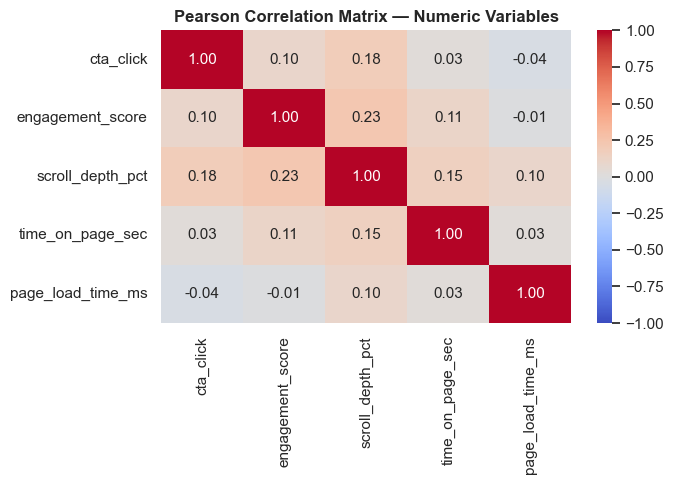

In [12]:
# Pearson correlation matrix — numeric variables
corr_vars = ['cta_click','engagement_score', 'scroll_depth_pct', 
             'time_on_page_sec', 'page_load_time_ms']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    df[corr_vars].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0, ax=ax,
    annot_kws={'size': 11}
)
ax.set_title('Pearson Correlation Matrix — Numeric Variables', fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Matrix Explained
The correlation matrix shows weak to negligible relationships across all variable pairs, which is expected for a low-frequency binary outcome in a short experiment. The strongest association with cta_click is scroll_depth_pct (r = 0.18), which makes sense as the CTA is positioned lower on the page. page_load_time_ms is essentially uncorrelated with everything (r = -0.04), ruling out page speed as a confound. The moderate correlation between engagement_score and scroll_depth_pct (r = 0.23) is expected since both capture similar visitor behavior, but not strong enough to cause concern.
No strong correlations with cta_click confirm that the outcome is not being driven by any single continuous variable, which is what we want in a randomised experiment.

### 2.7 CTA click rate bar chart + 95% CI

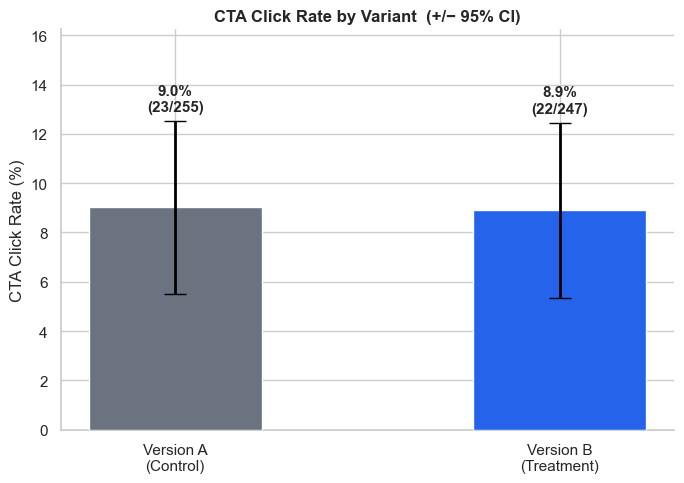

In [13]:
# CTA click rate bar chart
conv = df.groupby('variant')['cta_click'].agg(['mean', 'count', 'sum'])
conv['ci95'] = 1.96 * np.sqrt(conv['mean'] * (1 - conv['mean']) / conv['count'])

rates = conv['mean'].values * 100
cis   = conv['ci95'].values * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(['Version A\n(Control)', 'Version B\n(Treatment)'],
              rates, color=[GRAY, BLUE], width=0.45, zorder=3)

ax.errorbar(['Version A\n(Control)', 'Version B\n(Treatment)'],
            rates, yerr=cis,
            fmt='none', color='black', capsize=8, lw=2, zorder=4)

for bar, r, ci, clicks, n in zip(bars, rates, cis,
                                   conv['sum'].values, conv['count'].values):
    ax.text(bar.get_x() + bar.get_width() / 2, r + ci + 0.4,
            f'{r:.1f}%\n({int(clicks)}/{int(n)})',
            ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('CTA Click Rate (%)')
ax.set_title('CTA Click Rate by Variant  (+/− 95% CI)', fontweight='bold')
ax.set_ylim(0, max(rates) * 1.8)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### CTA Click Rate — Primary KPI

Version B achieved a CTA click rate of 8.9% (22/247) compared to 9.0% (23/255) for Version A, a difference of -0.1 percentage points. The 95% confidence intervals overlap substantially, which is an early visual signal that the treatment had little to no effect. The formal z-test and ATE estimation are carried out in Section 4.

### 2.8 KPI distributions

IQR Outlier Check
Variable                   Variant      Q1      Q3     IQR    Lower    Upper  Outliers
------------------------------------------------------------------------------
engagement_score                 A    5.77   32.22   26.45   -33.91    71.91         6
engagement_score                 B    5.39   43.32   37.93   -51.50   100.22         0

scroll_depth_pct                 A    4.68   50.89   46.21   -64.63   120.20         0
scroll_depth_pct                 B    6.15   63.30   57.15   -79.57   149.02         0

time_on_page_sec                 A   11.75  192.65  180.90  -259.60   464.00        20
time_on_page_sec                 B    9.90  168.75  158.85  -228.37   407.02        31



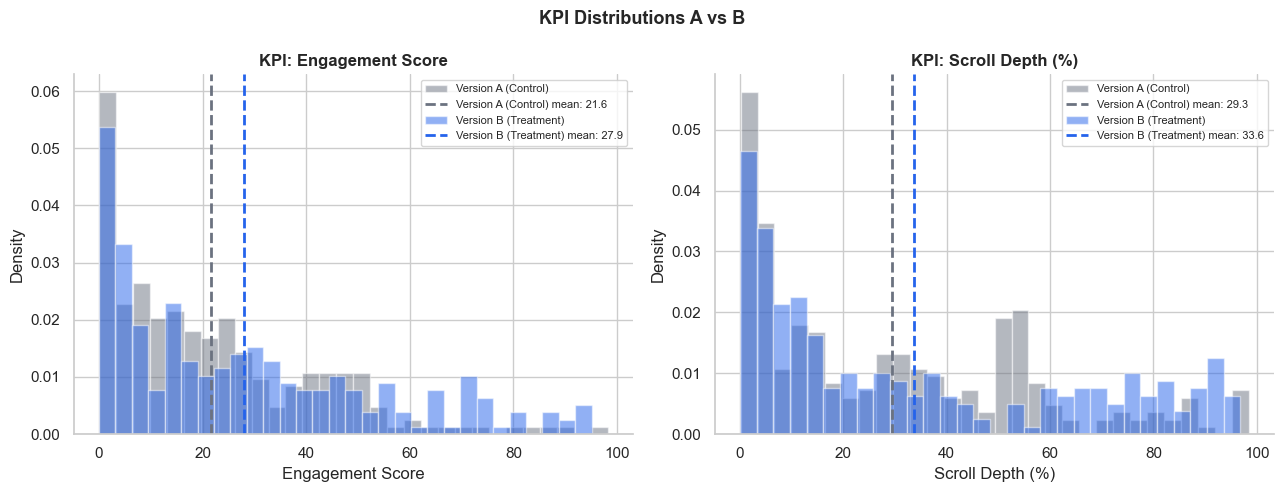

In [14]:
# IQR outlier flagging — per variant
continuous_vars = ['engagement_score', 'scroll_depth_pct', 'time_on_page_sec']

print('IQR Outlier Check')
print('=' * 78)
print(f'{"Variable":25s} {"Variant":>8} {"Q1":>7} {"Q3":>7} {"IQR":>7} {"Lower":>8} {"Upper":>8} {"Outliers":>9}')
print('-' * 78)

for col in continuous_vars:
    for variant in ['A', 'B']:
        grp = df[df['variant'] == variant][col].dropna()
        Q1, Q3 = grp.quantile(0.25), grp.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((grp < lower) | (grp > upper)).sum()
        print(f'{col:25s} {variant:>8} {Q1:>7.2f} {Q3:>7.2f} {IQR:>7.2f} '
              f'{lower:>8.2f} {upper:>8.2f} {n_out:>9}')
    print()
# Guiderail distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in zip(axes,
                           ['engagement_score', 'scroll_depth_pct'],
                           ['Engagement Score', 'Scroll Depth (%)']):
    for variant, color, name in zip(['A', 'B'],
                                     [GRAY, BLUE],
                                     ['Version A (Control)', 'Version B (Treatment)']):
        grp = df[df['variant'] == variant][col]
        ax.hist(grp, bins=30, alpha=0.5, color=color, label=name, density=True)
        ax.axvline(grp.mean(), color=color, lw=2, ls='--',
                   label=f'{name} mean: {grp.mean():.1f}')

    ax.set_title(f'KPI: {label}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('KPI Distributions A vs B', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### KPI Distributions explained

Both plots compare Version A and Version B on two KPI metrics to check whether the groups are comparable.

**Engagement Score (left)**
Both distributions are right-skewed, with most visitors concentrated at low engagement scores and a long tail toward 100. The means differ somewhat: A = 21.6, B = 27.9. The shapes overlap broadly but Version B sits slightly higher, which is worth noting.

**Scroll Depth (right)**
Similar pattern, heavily concentrated at low scroll depths with a spread across the full range. Means are A = 29.3% vs B = 33.6%, again a modest difference in the same direction.

**Key takeaway:** Both metrics show Version B with slightly higher means than Version A. The formal balance check in the next section will determine whether these differences are statistically significant or within the range of random variation.

### 2.9 Time on page distribution

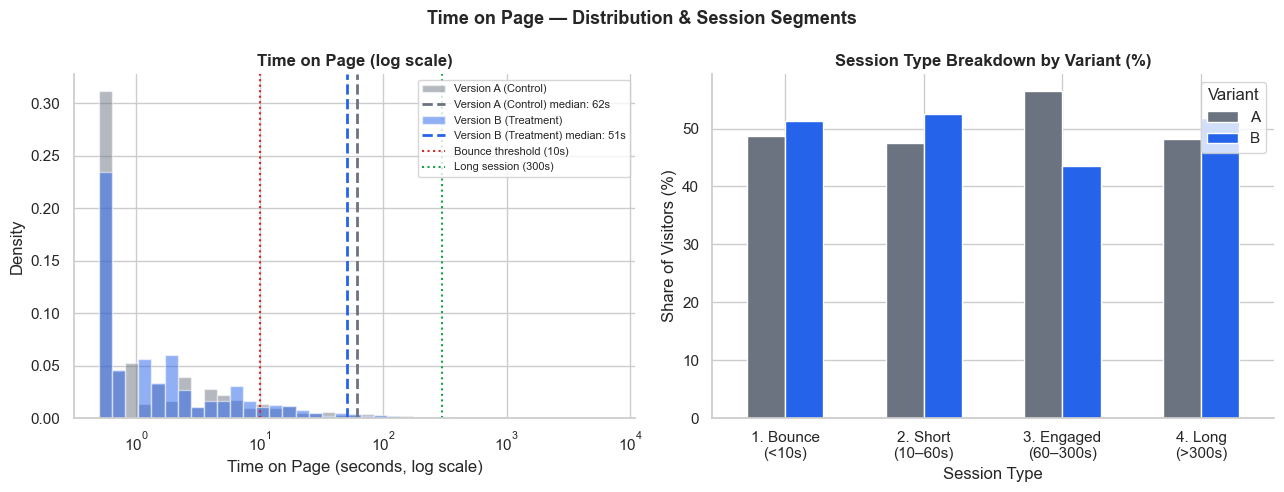

In [15]:
# Time on page distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: log-scale histogram
bins = np.logspace(np.log10(0.5), np.log10(df['time_on_page_sec'].max() + 1), 40)

for variant, color, name in zip(['A', 'B'],
                                  [GRAY, BLUE],
                                  ['Version A (Control)', 'Version B (Treatment)']):
    grp = df[df['variant'] == variant]['time_on_page_sec']
    axes[0].hist(grp, bins=bins, alpha=0.5, color=color, label=name, density=True)
    axes[0].axvline(grp.median(), color=color, lw=2, ls='--',
                    label=f'{name} median: {grp.median():.0f}s')

axes[0].axvline(10,  color=RED,   ls=':', lw=1.5, label='Bounce threshold (10s)')
axes[0].axvline(300, color=GREEN, ls=':', lw=1.5, label='Long session (300s)')
axes[0].set_xscale('log')
axes[0].set_title('Time on Page (log scale)', fontweight='bold')
axes[0].set_xlabel('Time on Page (seconds, log scale)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2: session type breakdown
def session_bucket(t):
    if t < 10:    return '1. Bounce\n(<10s)'
    elif t < 60:  return '2. Short\n(10–60s)'
    elif t < 300: return '3. Engaged\n(60–300s)'
    else:         return '4. Long\n(>300s)'

df['session_type'] = df['time_on_page_sec'].apply(session_bucket)

dist = (df.groupby(['session_type', 'variant'])
          .size()
          .unstack(fill_value=0))
dist_pct = dist.div(dist.sum(axis=1), axis=0) * 100

dist_pct.plot(kind='bar', ax=axes[1], color=[GRAY, BLUE],
              width=0.55, edgecolor='white')
axes[1].set_title('Session Type Breakdown by Variant (%)', fontweight='bold')
axes[1].set_xlabel('Session Type')
axes[1].set_ylabel('Share of Visitors (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Variant')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Time on Page — Distribution & Session Segments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Time on Page explained

Both distributions are heavily right-skewed, with most sessions under 10 seconds. Version A has a slightly higher median (62s) than Version B (51s), though the difference is modest and the distributions overlap closely throughout.

**Right panel: session type breakdown**
The distributions across session types are broadly similar between groups. Version B has slightly more bounce (<10s) and short (10-60s) sessions, while Version A has more engaged (60-300s) sessions. The long (>300s) bucket is nearly equal.

**Key takeaway:** Time on page is broadly comparable between the two groups, with no dramatic differences in session behavior. Given that CTA click rates are also nearly identical (9.0% vs 8.9%), this is consistent with the treatment having little measurable effect on how visitors interacted with the page.

### 2.10 Balance check table

In [16]:
# ── Balance check ─────────────────────────────────────────────────────────────
guiderails = [
    ('engagement_score',  'Engagement score'),
    ('scroll_depth_pct',  'Scroll depth (%)'),
    ('time_on_page_sec',  'Time on page (s)'),
    ('page_load_time_ms', 'Page load time (ms)'),
]

print('Balance Check — Guiderail Metrics')
print('=' * 74)
print(f'{"Metric":25s} {"Control (A)":>11} {"Treat (B)":>10} {"Diff":>8} {"SE":>8} {"p-value":>9} {"":>4}')
print('-' * 74)

for col, label in guiderails:
    a = df[df['variant'] == 'A'][col].dropna()
    b = df[df['variant'] == 'B'][col].dropna()
    diff = b.mean() - a.mean()
    se   = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))
    _, p = stats.ttest_ind(a, b, equal_var=False)
    sig  = 'X' if p < 0.05 else '✓'
    print(f'{label:25s} {a.mean():>11.3f} {b.mean():>10.3f} {diff:>+8.3f} {se:>8.3f} {p:>9.4f}  {sig}')

print()
print('✓ p > 0.05 — groups are balanced on this metric')
print('X  p < 0.05 — statistically significant difference, potential confound')

Balance Check — Guiderail Metrics
Metric                    Control (A)  Treat (B)     Diff       SE   p-value     
--------------------------------------------------------------------------
Engagement score               21.589     27.921   +6.331    2.031    0.0019  X
Scroll depth (%)               29.324     33.613   +4.289    2.594    0.0988  ✓
Time on page (s)              297.131    270.129  -27.002   75.502    0.7208  ✓
Page load time (ms)          1864.777   2312.436 +447.659  143.099    0.0019  X

✓ p > 0.05 — groups are balanced on this metric
X  p < 0.05 — statistically significant difference, potential confound


#### Balance Check explained

Two of the four guiderail metrics show **p < 0.05**, meaning the groups are not fully balanced on all dimensions.

- **Scroll depth** (p = 0.099) and **time on page** (p = 0.721) are balanced, with no statistically significant differences between groups.
- **Engagement score** (p = 0.002) and **page load time** (p = 0.002) show statistically significant differences between A and B, which is a concern.

**Key takeaway:** The randomization was not perfect. The significant difference in engagement score means Version B visitors were more engaged on average before any treatment effect, and Version B also experienced longer page load times. These are potential confounds that limit how confidently we can attribute any difference in CTA click rate to the treatment alone, and are an honest threat to the internal validity of this experiment.

---
## 3. Estimator Choice

Our test is a randomised A/B test, a field experiment where visitors are randomly assigned to control or treatment. Random assignment means treatment is independent of potential outcomes, so difference-in-means is an unbiased ATE estimator. We don't need matching, IV, or DiD.

We validate with OLS regression, which gives the same ATE but extends naturally to heterogeneous effects.

*Caveat: in our real ROOTKey test we observed a 4:1 traffic imbalance, suggesting randomisation may not have worked perfectly; a threat to internal validity discussed in Section 5.*


---
## 4. Formal Test: ATE, Regression & HTE

**ATE = E[Y | Treatment] − E[Y | Control] = μ_B − μ_A**

- H₀: ATE = 0
- H₁: ATE ≠ 0  (two-tailed, α = 0.05)


In [17]:
g_A = df[df['variant']=='A']['cta_click']
g_B = df[df['variant']=='B']['cta_click']
n_A, n_B   = len(g_A), len(g_B)
mu_A, mu_B = g_A.mean(), g_B.mean()

ATE     = mu_B - mu_A
se_ate  = np.sqrt(mu_A*(1-mu_A)/n_A + mu_B*(1-mu_B)/n_B)
ci_low  = ATE - 1.96 * se_ate
ci_high = ATE + 1.96 * se_ate
z_stat  = ATE / se_ate
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print('ATE — Difference-in-means')
print('=' * 50)
print(f'  mu_A (Control):     {mu_A*100:.2f}%')
print(f'  mu_B (Treatment):   {mu_B*100:.2f}%')
print(f'  ATE:                {ATE*100:.2f} pp')
print(f'  SE:                 {se_ate*100:.3f} pp')
print(f'  95% CI:             [{ci_low*100:.2f}pp, {ci_high*100:.2f}pp]')
print(f'  z-statistic:        {z_stat:.4f}')
print(f'  p-value:            {p_value:.4f}')
print()
if p_value < 0.05:
    print('  REJECT H0 — significant at alpha=0.05')
    print(f'  Treatment increases CTA click rate by {ATE*100:.2f}pp on average.')
else:
    print('  FAIL TO REJECT H0 — not significant at alpha=0.05')
    print(f'  95% CI [{ci_low*100:.2f}pp, {ci_high*100:.2f}pp] includes zero.')


ATE — Difference-in-means
  mu_A (Control):     9.02%
  mu_B (Treatment):   8.91%
  ATE:                -0.11 pp
  SE:                 2.550 pp
  95% CI:             [-5.11pp, 4.89pp]
  z-statistic:        -0.0442
  p-value:            0.9647

  FAIL TO REJECT H0 — not significant at alpha=0.05
  95% CI [-5.11pp, 4.89pp] includes zero.


The ATE is estimated as the difference in mean CTA click rates between treatment and control: μ_B − μ_A = -0.11pp. The standard error is calculated from the binomial variance of each group, giving a 95% confidence interval of [-5.11pp, 4.89pp]. The z-statistic of -0.0442 corresponds to a p-value of 0.965.

Since p > 0.05, we fail to reject H0. There is not sufficient evidence at the 5% significance level to conclude that Version B produces a different CTA click rate than Version A.

In [18]:
# OLS regression — validate ATE
X_raw = (df['variant'] == 'B').astype(int).values
y_raw = df['cta_click'].values
n     = len(y_raw)
X_mat = np.column_stack([np.ones(n), X_raw])

beta     = np.linalg.lstsq(X_mat, y_raw, rcond=None)[0]
y_hat    = X_mat @ beta
resid    = y_raw - y_hat
s2       = (resid @ resid) / (n - 2)
var_beta = s2 * np.linalg.inv(X_mat.T @ X_mat)
se_beta  = np.sqrt(np.diag(var_beta))
t_reg    = beta / se_beta
p_reg    = 2 * (1 - stats.t.cdf(np.abs(t_reg), df=n-2))
r2       = 1 - (resid@resid) / ((y_raw-y_raw.mean())@(y_raw-y_raw.mean()))

print('OLS: cta_click ~ treatment')
print('=' * 58)
print(f'{"Variable":25s} {"Coef":>8}  {"SE":>8}  {"t":>7}  {"p":>8}')
print('-' * 58)
for lbl, b, se, t, p in zip(['Intercept (Control)', 'Treatment (B)'],
                              beta, se_beta, t_reg, p_reg):
    sig = '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{lbl:25s} {b:>8.4f}  {se:>8.4f}  {t:>7.3f}  {p:>8.4f} {sig}')
print('-' * 58)
print(f'R2: {r2:.4f}   N: {n}')
print()
print(f'Treatment coef = {beta[1]*100:.2f}pp — matches ATE exactly.')


OLS: cta_click ~ treatment
Variable                      Coef        SE        t         p
----------------------------------------------------------
Intercept (Control)         0.0902    0.0179    5.032    0.0000 **
Treatment (B)              -0.0011    0.0256   -0.044    0.9648 
----------------------------------------------------------
R2: 0.0000   N: 502

Treatment coef = -0.11pp — matches ATE exactly.


The OLS regression confirms the ATE estimate. The intercept (0.0902) represents the baseline CTA click rate for the control group, which matches μ_A exactly. The treatment coefficient (-0.0011) represents the estimated effect of being assigned to Version B, and is identical to the difference-in-means ATE above. This consistency between the two methods is expected in a randomized experiment and validates the result. The R² is very low (0), which is also expected since treatment assignment alone explains only a small fraction of individual-level variation in a binary outcome.

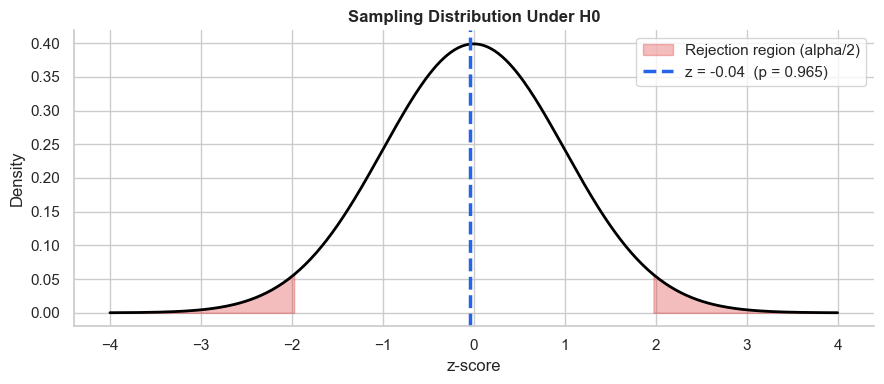

In [19]:
# Sampling distribution under H0
fig, ax = plt.subplots(figsize=(9, 4))
x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)
ax.plot(x, y, color='black', lw=2)
ax.fill_between(x, y, where=(x <= -1.96), color=RED, alpha=0.3, label='Rejection region (alpha/2)')
ax.fill_between(x, y, where=(x >=  1.96), color=RED, alpha=0.3)
ax.axvline(z_stat, color=BLUE, lw=2.5, ls='--',
           label=f'z = {z_stat:.2f}  (p = {p_value:.3f})')
ax.set_title('Sampling Distribution Under H0', fontweight='bold')
ax.set_xlabel('z-score')
ax.set_ylabel('Density')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


The plot shows the standard normal distribution under H0, with the rejection 
regions shaded in red beyond ±1.96. The blue dashed line marks our observed 
z-statistic of -0.04. Since it falls well inside the non-rejection region, 
we fail to reject H0 at α = 0.05.


In [20]:
# HTE — high vs low engagement subgroups
# Split on median engagement_score
med_engage = df['engagement_score'].median()
df['high_engage'] = (df['engagement_score'] >= med_engage).astype(int)

print('HTE: Subgroup segmentation (high vs low engagement)')
print('=' * 90)
print(f'{"Subgroup":28s} {"n_A":>6} {"n_B":>6} {"ATE (pp)":>10} {"95% CI":>22} {"p":>8}')
print('-' * 90)

for label, mask in [('High engagement', df['high_engage']==1),
                    ('Low engagement',  df['high_engage']==0)]:
    sub = df[mask]
    sA  = sub[sub['variant']=='A']['cta_click']
    sB  = sub[sub['variant']=='B']['cta_click']
    ate_s = sB.mean() - sA.mean()
    se_s  = np.sqrt(sA.mean()*(1-sA.mean())/len(sA) + sB.mean()*(1-sB.mean())/len(sB))
    z_s   = ate_s / se_s if se_s > 0 else 0
    p_s   = 2 * (1 - stats.norm.cdf(abs(z_s)))
    ci_s  = (ate_s - 1.96*se_s, ate_s + 1.96*se_s)
    print(f'{label:28s} {len(sA):>6} {len(sB):>6} {ate_s*100:>+10.2f}  '
          f'[{ci_s[0]*100:.1f}pp, {ci_s[1]*100:.1f}pp]  {p_s:>8.4f}')


HTE: Subgroup segmentation (high vs low engagement)
Subgroup                        n_A    n_B   ATE (pp)                 95% CI        p
------------------------------------------------------------------------------------------
High engagement                 119    132      +1.87  [-6.4pp, 10.1pp]    0.6559
Low engagement                  136    115      -3.14  [-8.5pp, 2.2pp]    0.2505


High-engagement visitors show a small positive ATE of +1.87pp, while low-engagement visitors show a negative ATE of -3.14pp. However, neither result is statistically significant (p = 0.656 and p = 0.251 respectively), and both confidence intervals include zero by a wide margin.

The opposite signs are interesting directionally, suggesting the treatment may have resonated slightly more with engaged visitors while having no benefit, or even a slightly negative effect, on low-engagement ones. However, with roughly half the sample in each subgroup, power is reduced further, so these results should be treated as exploratory rather than conclusive.

In [21]:
# HTE interaction regression
treat_v    = (df['variant'] == 'B').astype(int).values
engage_v   = df['high_engage'].values
inter_v    = treat_v * engage_v
y_v        = df['cta_click'].values
n_v        = len(y_v)
X_v        = np.column_stack([np.ones(n_v), treat_v, engage_v, inter_v])

b_v   = np.linalg.lstsq(X_v, y_v, rcond=None)[0]
yh_v  = X_v @ b_v
res_v = y_v - yh_v
s2_v  = (res_v @ res_v) / (n_v - 4)
var_v = s2_v * np.linalg.inv(X_v.T @ X_v)
se_v  = np.sqrt(np.diag(var_v))
t_v   = b_v / se_v
p_v   = 2 * (1 - stats.t.cdf(np.abs(t_v), df=n_v-4))
r2_v  = 1 - (res_v@res_v)/((y_v-y_v.mean())@(y_v-y_v.mean()))

print('OLS: cta_click ~ treatment + high_engage + treatment x high_engage')
print('=' * 62)
print(f'{"Variable":28s} {"Coef":>8}  {"SE":>8}  {"t":>7}  {"p":>8}')
print('-' * 62)
for lbl, b, se, t, p in zip(['Intercept', 'Treatment (B)',
                               'High engage', 'Treatment x High engage'],
                              b_v, se_v, t_v, p_v):
    sig = '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{lbl:28s} {b:>8.4f}  {se:>8.4f}  {t:>7.3f}  {p:>8.4f} {sig}')
print('-' * 62)
print(f'R2: {r2_v:.4f}   N: {n_v}')
print()
print(f'ATE for low engagement:  {b_v[1]*100:.2f}pp')
print(f'ATE for high engagement: {(b_v[1]+b_v[3])*100:.2f}pp  (= treatment + interaction)')


OLS: cta_click ~ treatment + high_engage + treatment x high_engage
Variable                         Coef        SE        t         p
--------------------------------------------------------------
Intercept                      0.0662    0.0244    2.718    0.0068 **
Treatment (B)                 -0.0314    0.0360   -0.873    0.3833 
High engage                    0.0515    0.0356    1.444    0.1494 
Treatment x High engage        0.0501    0.0508    0.986    0.3246 
--------------------------------------------------------------
R2: 0.0196   N: 502

ATE for low engagement:  -3.14pp
ATE for high engagement: 1.87pp  (= treatment + interaction)


The interaction regression formalizes the subgroup analysis. The model is:

**cta_click ~ treatment + high_engage + treatment x high_engage**

The treatment coefficient gives the ATE for low-engagement visitors. The interaction term (treatment x high_engage) captures whether the treatment effect differs for high-engagement visitors.

The treatment coefficient is -0.0314 (p = 0.383), confirming no significant effect for low-engagement visitors. The interaction term is +0.0501 (p = 0.325), meaning the treatment effect is 5pp higher for high-engagement visitors than for low-engagement ones, but this difference is not statistically significant either.

Neither the treatment nor the interaction term reaches significance, and the R2 of 0.02 confirms the model explains almost none of the variation in CTA click rate. There is no evidence of heterogeneous treatment effects by engagement level in this dataset.

---
## 5. Validity

### Internal Validity
Can we causally attribute the result to the treatment?

The professor's dataset uses random assignment, which in principle eliminates 
selection bias. However, the balance check revealed statistically significant 
differences between groups on engagement score and page load time, which are 
potential confounds. This limits how confidently we can attribute any difference 
in CTA click rate to the treatment alone.

In our real ROOTKey test, internal validity was further compromised by a 4:1 
traffic imbalance of unknown origin, and the fact that all tracking was on the 
company's side with no independent verification.

### External Validity
Do results generalize beyond this test?

The dataset comes from a single landing page over a short window, with traffic 
drawn from a specific audience at a specific point in time. Results may not 
generalize to different traffic sources, time periods, or page contexts. The 
sample size is also modest, which limits the precision of our estimates and 
reduces confidence in any broader conclusions.


---
## 6. Discussion

**Did we find what we expected?**
No. We hypothesized that Version B would produce a higher CTA click rate than 
Version A. In practice, the rates were nearly identical: 8.9% vs 9.0%, a 
difference of -0.1pp in the wrong direction.

**Was the effect weaker, stronger, or inexistent?**
Effectively inexistent. The ATE of -0.11pp is negligible and statistically 
indistinguishable from zero (p = 0.965). The 95% confidence interval of 
[-5.11pp, 4.89pp] is wide enough to include both a meaningful positive and 
a meaningful negative effect, so we cannot draw strong conclusions in either 
direction.

**Did the power calculations hold up?**
No. We needed 503 visitors per group and had 255 and 247 respectively, meaning 
the experiment was underpowered to detect a 2pp effect. The wide confidence 
interval is a direct consequence of this. The null result is inconclusive rather 
than definitive evidence that the treatment does not work.
